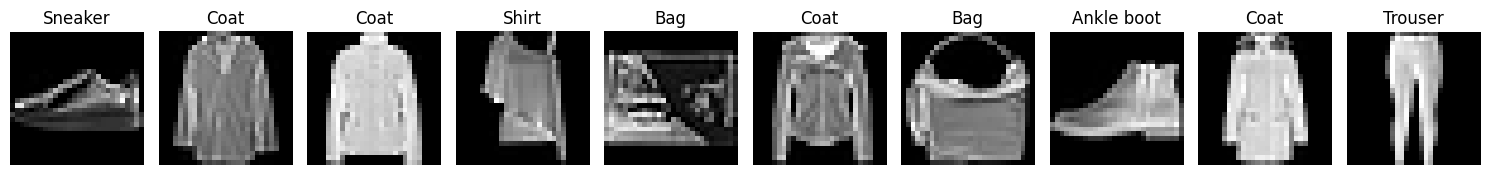

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets.fashion_mnist import load_data
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

(X_train, y_train), (X_test, y_test) = load_data()

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

indices = np.random.choice(len(X_train), 10)

images = X_train[indices]
labels = y_train[indices]

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
train_images_f = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
test_images_f  = X_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

In [40]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

tf.random.set_seed(42)

model_guide = Sequential([
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_FashionMNIST_Optimised')

optimizer = Adam(learning_rate=0.001)

model_guide.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_guide.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_FashionMNIST_Optimised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,867,466 (7.12 MB)

 Trainable params: 1,867,466 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8087 - loss: 0.5274 - val_accuracy: 0.8795 - val_loss: 0.3200
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8860 - loss: 0.3155 - val_accuracy: 0.9033 - val_loss: 0.2566
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9025 - loss: 0.2635 - val_accuracy: 0.9134 - val_loss: 0.2317
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9135 - loss: 0.2335 - val_accuracy: 0.9195 - val_loss: 0.2188
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9235 - loss: 0.2100 - val_accuracy: 0.9222 - val_loss: 0.2141
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9293 - loss: 0.1924 - val_accuracy: 0.9187 - val_loss: 0.2157
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9353 - loss: 0.1758 - val_accuracy: 0.9299 - val_loss: 0.2134
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9377 - loss: 0.1674 - val_acc

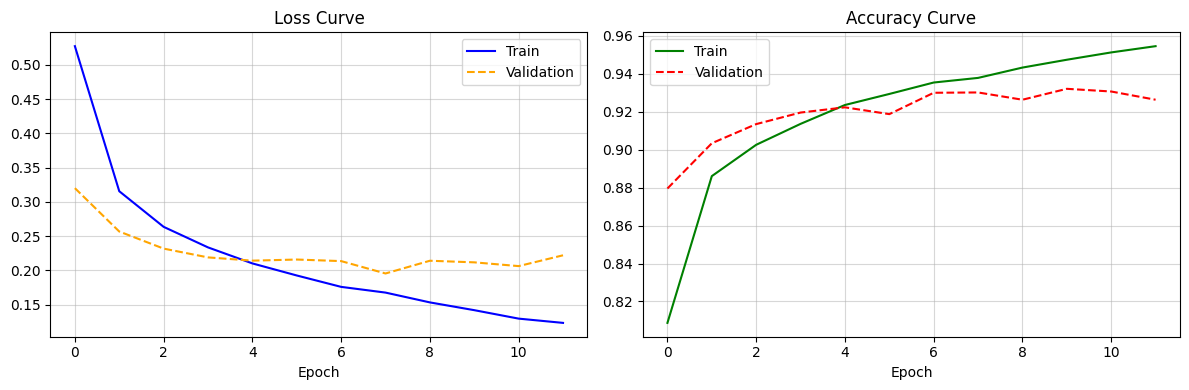

In [41]:
callback = EarlyStopping(monitor='loss',patience=3,verbose=0,restore_best_weights=True)
 
history = model_guide.fit(
    train_images_f, y_train,
    epochs=12,
    batch_size=128,
    validation_split=0.2,
    callbacks=[callback],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train',      color='blue')
ax1.plot(history.history['val_loss'], label='Validation', color='orange', linestyle='--')
ax1.set_title('Loss Curve'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.5)
ax2.plot(history.history['accuracy'],     label='Train',      color='green')
ax2.plot(history.history['val_accuracy'], label='Validation', color='red', linestyle='--')
ax2.set_title('Accuracy Curve'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.5)
plt.tight_layout(); plt.show()

## Test Evaluation

This section performs a comprehensive evaluation of the trained model on the held-out test set. It covers:
- Global test accuracy and loss
- Confusion matrix
- Per-class precision, recall and F1-score (classification report)
- Visual inspection of sample predictions (correct and incorrect)

In [42]:
test_loss, test_acc = model_guide.evaluate(test_images_f, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

Test Loss     : 0.2342
Test Accuracy : 92.42%


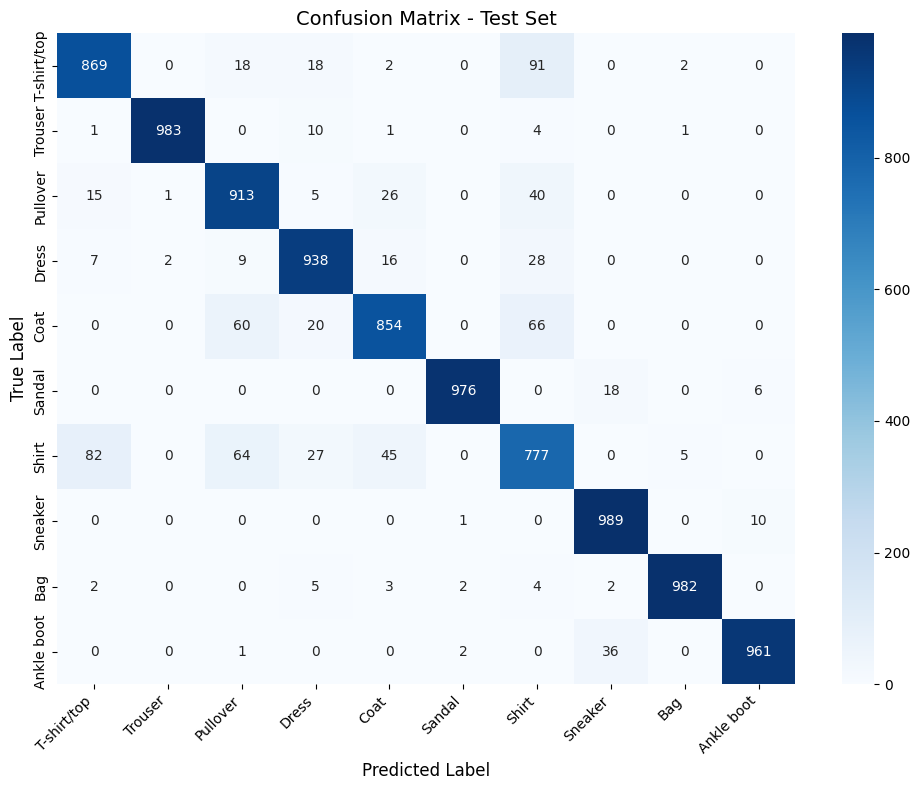

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.87      0.88      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.86      0.91      0.88      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.90      0.85      0.88      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.77      0.78      0.77      1000
     Sneaker       0.95      0.99      0.97      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model_guide.predict(test_images_f, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=classes))

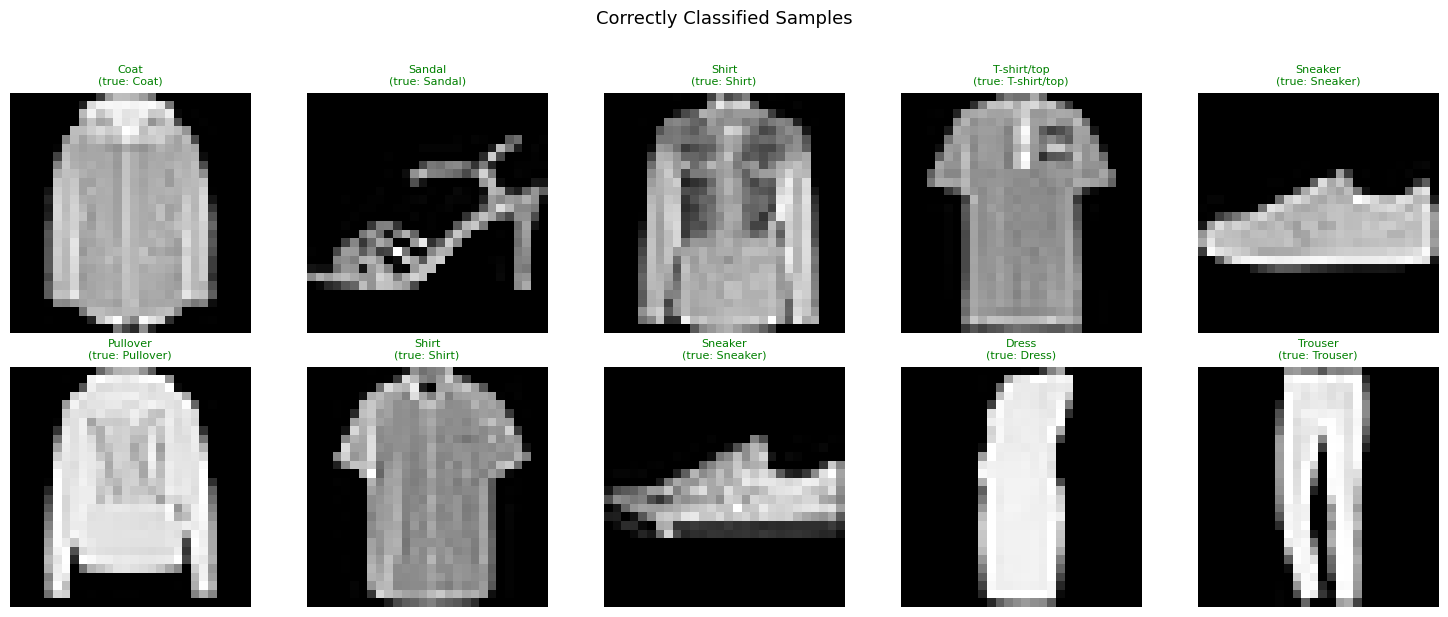

In [44]:
import numpy as np

def show_predictions(images, y_true, y_pred, class_names, title=''):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        ax.imshow(images[i].reshape(28, 28), cmap='gray')
        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]
        correct    = y_true[i] == y_pred[i]
        color      = 'green' if correct else 'red'
        ax.set_title(f"{pred_label}\n(true: {true_label})", color=color, fontsize=8)
        ax.axis('off')
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

correct_idx   = np.where(y_pred == y_test)[0]

np.random.seed(42)
sample_correct   = np.random.choice(correct_idx, 10, replace=False)

show_predictions(
    test_images_f[sample_correct], y_test[sample_correct], y_pred[sample_correct],
    classes, title='Correctly Classified Samples'
)
